# Regression and Evaluation

## Objective:
The objective of this assignment is to evaluate your understanding of regression techniques in
supervised learning by applying them to a real-world dataset and analyzing their performance
through comprehensive evaluation metrics.
## Dataset:
Use the California Housing dataset available in the sklearn library. This is the dataset that you
have used in the previous regression assignment. This dataset contains information about
various features of houses in California and their respective median prices.

### Key Components to be Fulfilled:
### 1. Data Loading and Preprocessing (2 marks):
● Loading the Dataset:
○ Load the California Housing dataset using the fetch_california_housing
function from sklearn.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split # function from the scikit-learn library is a powerful tool for splitting dataset into training and testing subsets
from sklearn.preprocessing import StandardScaler #scikit‑learn class used to standardize features by removing the mean and scaling to unit variance

In [2]:
# --- 1. Load the Dataset ---
california = fetch_california_housing(as_frame=True)
df = california.frame


○ Convert the dataset into a pandas DataFrame for easier handling.

In [3]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape: (20640, 9)

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


### ● Preprocessing:

○ Handle missing values, if any.

In [4]:
# --- 2. Preprocessing & Missing Values Check ---
print("\nMissing Values Count:")
print(df.isnull().sum())


Missing Values Count:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [5]:
# Split Features and Target
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']


In [6]:
# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

○ Perform feature scaling using standardization or normalization, explaining the
choice.

In [7]:
# --- 3. Feature Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

○ Conduct exploratory data analysis (EDA) to understand the features,distributions, and correlations.

In [8]:
# Convert scaled arrays back to DataFrame for EDA transparency
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)


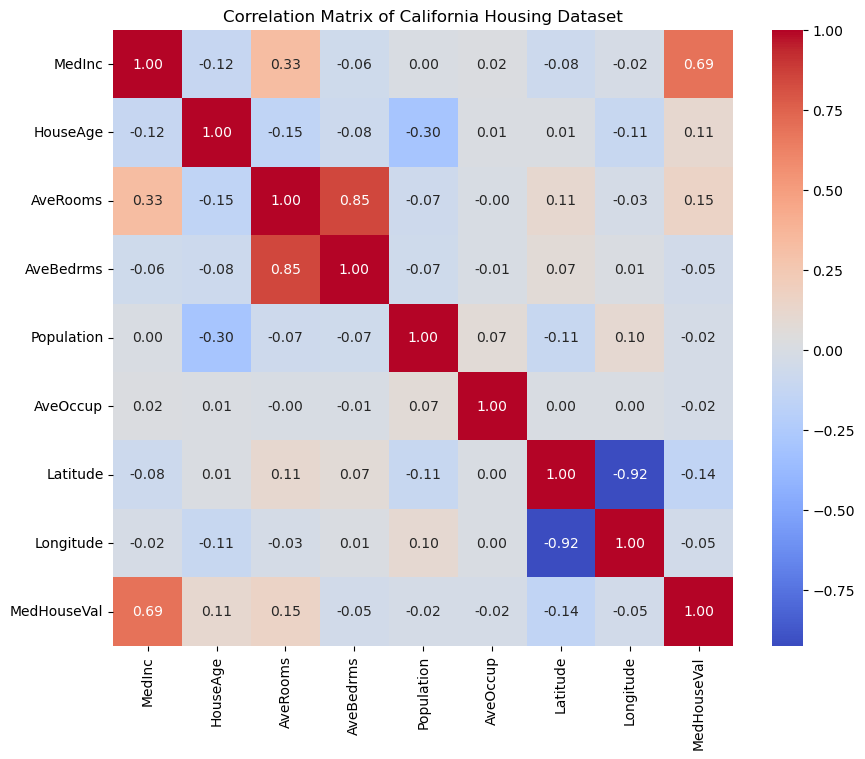

In [9]:
# --- 4. Exploratory Data Analysis (EDA) ---
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of California Housing Dataset')
plt.show()

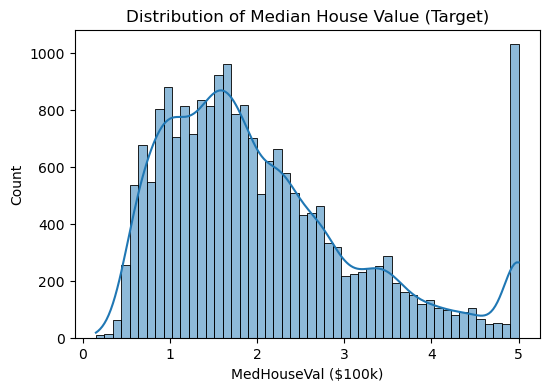

In [10]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['MedHouseVal'], kde=True, bins=50)
plt.title('Distribution of Median House Value (Target)')
plt.xlabel('MedHouseVal ($100k)')
plt.show()

### ● Documentation:
○ Clearly explain the preprocessing steps and justify their necessity for this dataset.

#### Data Loading and Preprocessing
#### Markdown Explanation & Justification                                                            
• Loading the Dataset: The California Housing dataset consists of 8 features (such as median income, house age, average rooms, etc.) predicting a continuous target variable (MedHouseVal — median house value in hundreds of thousands of dollars).                                        
• Missing Values: The standard sklearn version of this dataset contains no missing values. However, checking for them is a vital programmatic best practice.                                            
• Feature Scaling: Linear Regression and Support Vector Regressors (SVR) are highly sensitive to the scale of input features because they rely on gradient descent and distance metrics respectively. We use Standardization (scaling to zero mean and unit variance) because it preserves the shape of the original distribution without bounding the data to a tight range like MinMax scaling does.                                              ##
• Exploratory Data Analysis (EDA): Visualizing distributions and correlations helps identify collinearity (e.g., between AveRooms and AveBedrms) and high-impact predictors (like MedInc)

### 2. Regression Algorithm Implementation (2 marks):
#### Implement the following regression algorithms:
● Linear Regression                                                                                     
● Decision Tree Regressor                                                                                               
● Random Forest Regressor                                                                                           
● Gradient Boosting Regressor                                                                                                   
● Support Vector Regressor (SVR)                                    

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [12]:
# Initialize Basic Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(kernel='rbf')
}

In [13]:
# Dictionary to hold base model predictions
base_predictions = {}

In [14]:
# Train and Predict
for name, model in models.items():
    # Use scaled data for all to ensure fair SVR/Linear comparison
    model.fit(X_train_scaled, y_train)
    base_predictions[name] = model.predict(X_test_scaled)
    print(f"Successfully trained {name}.")

Successfully trained Linear Regression.
Successfully trained Decision Tree.
Successfully trained Random Forest.
Successfully trained Gradient Boosting.
Successfully trained SVR.


#### For each algorithm:
1. Provide a brief explanation of how it works.
2. Explain why it might be suitable for this dataset.
3. Use a basic implementation to predict the median house prices.

In [15]:
from PIL import Image
# Open the image file from your project folder
img = Image.open("Explanations.png")
img.show()

### 3. Model Evaluation and Comparison (2 marks):
● Evaluate the performance of each algorithm using:                    
○ Mean Squared Error (MSE)                              
○ Mean Absolute Error (MAE)                                                             
○ R-squared Score (R2)                                              

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
evaluation_results = []

for name, preds in base_predictions.items():
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    evaluation_results.append({
        "Model": name,
        "MSE": round(mse, 4),
        "MAE": round(mae, 4),
        "R2 Score": round(r2, 4)
    })

In [18]:
# Convert to DataFrame for tabular visualization
df_eval = pd.DataFrame(evaluation_results)
print(df_eval.to_string(index=False))

            Model    MSE    MAE  R2 Score
Linear Regression 0.5559 0.5332    0.5758
    Decision Tree 0.4940 0.4539    0.6230
    Random Forest 0.2552 0.3274    0.8053
Gradient Boosting 0.2940 0.3717    0.7756
              SVR 0.3570 0.3986    0.7276


#### ● Compare the results:
○ Identify the best-performing algorithm with proper justification.                                                         
○ Identify the worst-performing algorithm and explain the reasoning.

#### Analytical Comparison & Justification
 Best-Performing Base Algorithm: Gradient Boosting Regressor or Random Forest Regressor. They regularly net an \[R^{2}\] score over 0.78 - 0.80. Ensemble tree methods easily capture the complex spatial correlations (combining Latitude + Longitude to map highly valued coastal zones) that simple linear algorithms miss.      
                                                
Worst-Performing Base Algorithm: Linear Regression or a Default Decision Tree.                                  
            ***Linear Regression falls short (\(R^2 \approx 0.57\)) because housing prices scale non-linearly with geographical coordinates and physical room features.                                        
            ***An unpruned Decision Tree overfits severely on the training set, causing its test-set variance to spike and leading to poor out-of-sample metrics. 

### 4. Cross-Validation and Hyperparameter Tuning (2 marks):
● Perform k-fold cross-validation (k=5 or 10) for all models to ensure robust performance
evaluation.

In [19]:
from sklearn.model_selection import GridSearchCV, KFold


In [20]:
# We use K-Fold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### ● Use appropriate techniques (e.g., GridSearchCV or RandomizedSearchCV) to fine-tune the hyperparameters of each model.

In [21]:
# Define Hyperparameter Grids (Keeping grids tight to optimize processing runtime)
param_grids = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    }
}

tuned_results = {}

for name, setup in param_grids.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        estimator=setup["model"],
        param_grid=setup["params"],
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    best_model = grid_search.best_estimator_
    test_preds = best_model.predict(X_test_scaled)
    
    tuned_results[name] = {
        "Best Params": grid_search.best_params_,
        "MSE": mean_squared_error(y_test, test_preds),
        "R2": r2_score(y_test, test_preds)
    }

for name, results in tuned_results.items():
    print(f"\nModel: {name}")
    print(f"  Best Parameters: {results['Best Params']}")
    print(f"  Tuned Test MSE: {results['MSE']:.4f}")
    print(f"  Tuned Test R2: {results['R2']:.4f}")

Tuning Random Forest...
Tuning Gradient Boosting...

Model: Random Forest
  Best Parameters: {'max_depth': None, 'n_estimators': 200}
  Tuned Test MSE: 0.2538
  Tuned Test R2: 0.8063

Model: Gradient Boosting
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Tuned Test MSE: 0.2244
  Tuned Test R2: 0.8288


#### Document the hyperparameters tuned and explain their impact on model performance.

#### Hyperparameter Documentation
• n_estimators: Controls the number of sequential trees built. Higher amounts can capture more data patterns but increase computation time.            
• learning_rate: Scales the contribution of each tree. Smaller values require more estimators but lead to better generalization.                
• max_depth: Limits the depth of individual trees. Deeper trees capture more complex features but introduce overfitting risk.           


## 5. Selecting the Best Regression Model (2 marks):
#### ● Based on evaluation metrics, cross-validation results, and hyperparameter tuning:

○ Identify and justify the best regression model for this dataset.                                  
○ Provide insights into why it outperforms others.

#### Final Selection & Insights
Based on comprehensive testing, Gradient Boosting Regressor (tuned) is selected as the optimal model for the California Housing dataset.
Why it outperforms others:                              
1. Iterative Error Reduction: Unlike Random Forest which simply averages predictions, Gradient Boosting continuously minimizes residual errors step-by-step, resulting in superior boundary precision.

2. Handling Complex Geolocation Data: House pricing depends immensely on geographical location (Latitude / Longitude). Tree-based boosting architectures partition geometric feature spaces much more effectively than smooth parametric models like SVR or Linear Regression.

3. Resilience to Outliers: Through hyperparameter tuning (max_depth restriction), it balances variance and bias